### import psrcat file with P>=0.01 and V>=0 

In [1]:
# 读取文件，踢除双星系统
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Load the datasets
import csv
import pandas as pd
path = '/Users/lizheng/Desktop/code/period_velocity/period_velocity_0.01_psrcat.txt'
data = pd.read_fwf(
    path,
    infer_nrows=100,  # 使用前100行推断列宽
    skiprows=1,       # 跳过标题行
    header=None       # 不将第一行作为列名
)
# len is 317
bname=list(data[1])    # Pulsar Bname
jname = list(data[3])  # Pulsar jname
period=list(data[5])   # Pulsar period
age=list(data[8])      # Characteristic age
dist=list(data[9])     # Distance based on the YMW16
binary=list(data[10])  # Binary system or not
assoc=list(data[15])   # Other name such as SNR...
pmtot=list(data[17])   # Total proper motion (mas/yr)
vtrans=list(data[19])  # Transverse velocity based on DIST (km/s)
print(jname)
print(period)
print(age)
print(dist)
print(binary)
print(assoc)
print(pmtot)
print(vtrans)

['J0002+6216', 'J0014+4746', 'J0034-0721', 'J0040+5716', 'J0055+5117', 'J0102+6537', 'J0108+6608', 'J0108-1431', 'J0117+5914', 'J0134-2937', 'J0139+5814', 'J0146+6145', 'J0147+5922', 'J0151-0635', 'J0152-1637', 'J0157+6212', 'J0205+6449', 'J0206-4028', 'J0210+5845', 'J0214+5222', 'J0248+6021', 'J0255-5304', 'J0304+1932', 'J0323+3944', 'J0332+5434', 'J0335+4555', 'J0348+0432', 'J0357+3205', 'J0357+5236', 'J0358+5413', 'J0406+6138', 'J0415+6954', 'J0452-1759', 'J0453+1559', 'J0454+5543', 'J0502+4654', 'J0509+3801', 'J0514-4002I', 'J0525+1115', 'J0528+2200', 'J0534+2200', 'J0536-7543', 'J0538+2817', 'J0601-0527', 'J0612+3721', 'J0614+2229', 'J0621+1002', 'J0629+2415', 'J0630-2834', 'J0633+1746', 'J0653+8051', 'J0659+1414', 'J0700+6418', 'J0709+0458', 'J0720-3125', 'J0729-1836', 'J0738-4042', 'J0742-2822', 'J0745-5353', 'J0754+3231', 'J0758-1528', 'J0809-4753', 'J0814+7429', 'J0820-1350', 'J0821-4300', 'J0823+0159', 'J0826+2637', 'J0835-4510', 'J0837+0610', 'J0837-2454', 'J0837-4135', 'J08

In [2]:
print(len(vtrans))

315


In [3]:
print(pmtot[0])

35.3


In [4]:
len(binary)

315

### take all none binary system pulsars

In [5]:
# 提取所有 '*' 元素 len=254
stars= [i == '*' for i in binary]
bname_new=[ j for j, star in zip(bname, stars) if star]
jname_new=[ j for j, star in zip(jname, stars) if star]
period_new=[ j for j, star in zip(period, stars) if star]
age_new=[ j for j, star in zip(age, stars) if star]
dist_new=[ j for j, star in zip(dist, stars) if star]
binary_new=[ j for j, star in zip(binary, stars) if star]
assoc_new=[ j for j, star in zip(assoc, stars) if star]
pmtot_new=[ j for j, star in zip(pmtot, stars) if star]
vtrans_new=[ j for j, star in zip(vtrans, stars) if star]


In [6]:
print(len(vtrans_new))

254


### read pulsar parallax.txt 文件，确定距离

In [7]:
# 提取pulsar_parallax.txt中的脉冲星jname 及对应的parallaxes和误差
file_path = '/Users/lizheng/Desktop/code/period_velocity/pulsar_parallaxes.txt'
def extract_pulsar_data(file_path):
    pulsar_names = []  # 存储脉冲星JName的列表
    parallax_data = []  # 存储每个脉冲星的所有视差测量值
    
    current_pulsar = None
    current_measurements = []  # 当前脉冲星的测量值列表
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            
            # 跳过空行和注释
            if not line or line.startswith('#') or line.startswith('=========='):
                continue
            
            # 检测到新脉冲星
            if line.startswith('!!psr'):
                # 保存前一个脉冲星的数据
                if current_pulsar:
                    pulsar_names.append(current_pulsar)
                    parallax_data.append(current_measurements)
                
                # 重置当前脉冲星
                current_pulsar = None
                current_measurements = []
                continue
            
            # 处理键值对
            if '=' in line:
                key, value = [part.strip() for part in line.split('=', 1)]
                
                if key == 'JName':
                    current_pulsar = value
                elif key == 'PI' and current_pulsar:
                    # 初始化新的测量值字典
                    measurement = {'PI': value}
                    current_measurements.append(measurement)
                elif key in ['eplus', 'eminus'] and current_pulsar and current_measurements:
                    # 添加到当前测量值
                    current_measurements[-1][key] = value
    
    # 添加最后一个脉冲星
    if current_pulsar:
        pulsar_names.append(current_pulsar)
        parallax_data.append(current_measurements)
    
    return pulsar_names, parallax_data

# 使用示例
if __name__ == "__main__":
    file_path = "pulsar_parallaxes.txt"  
    pulsar_names, parallax_data = extract_pulsar_data(file_path)
    
    # 打印结果
    print(f"提取到 {len(pulsar_names)} 个脉冲星")
    print("\n脉冲星名称列表:")
    print(pulsar_names[:5])  # 打印前5个作为示例
    
    print("\n视差数据示例:")
    for i in range(min(3, len(pulsar_names))):  # 打印前3个脉冲星的视差数据
        print(f"\n{pulsar_names[i]} 的视差测量值:")
        for j, measurement in enumerate(parallax_data[i]):
            print(f"  测量 {j+1}: PI={measurement.get('PI', 'N/A')}, "
                  f"eplus={measurement.get('eplus', 'N/A')}, "
                  f"eminus={measurement.get('eminus', 'N/A')}")

print(pulsar_names)
print(parallax_data)

提取到 158 个脉冲星

脉冲星名称列表:
['J0030+0451', 'J0034-0721', 'J0040+5716', 'J0045-7319', 'J0055+5117']

视差数据示例:

J0030+0451 的视差测量值:
  测量 1: PI=3.02, eplus=+0.07, eminus=-0.07
  测量 2: PI=3.04, eplus=+0.05, eminus=-0.05
  测量 3: PI=3.3, eplus=+0.9, eminus=-0.9

J0034-0721 的视差测量值:
  测量 1: PI=0.93, eplus=+0.08, eminus=-0.07

J0040+5716 的视差测量值:
  测量 1: PI=0.102, eplus=+0.051, eminus=-0.025
['J0030+0451', 'J0034-0721', 'J0040+5716', 'J0045-7319', 'J0055+5117', 'J0102+6537', 'J0108-1431', 'J0108+6608', 'J0139+5814', 'J0147+5922', 'J0151-0635', 'J0152-1637', 'J0157+6212', 'J0212+5321', 'J0218+4232', 'J0323+3944', 'J0332+5434', 'J0335+4555', 'J0337+1715', 'J0357+5236', 'J0358+5413', 'J0406+6138', 'J0437-4715', 'J0452-1759', 'J0454+5543', 'J0509+3801', 'J0534+2200', 'J0538+2817', 'J0601-0527', 'J0610-2100', 'J0613-0200', 'J0614+2229', 'J0621+1002', 'J0629+2415', 'J0630-2834', 'J0633+1746', 'J0636+5129', 'J0645+5158', 'J0659+1414', 'J0720-3125', 'J0729-1836', 'J0737-3039B', 'J0751+1807', 'J0814+7429', 'J08

In [8]:
# 初始化结果列表
matched_names = []  # 存储匹配的名字
matched_vtrans = []  # 存储对应的 vtrans 值
matched_parallax = []  # 存储对应的 parallax_data 值
# 遍历 jname 列表
for i, name in enumerate(jname):
    if name in pulsar_names:
        # 获取在 pulsar_names 中的索引
        j = pulsar_names.index(name)
        # 记录匹配的名字
        matched_names.append(name)
        # 提取对应的 vtrans 和 parallax_data
        matched_vtrans.append(vtrans[i])
        matched_parallax.append(parallax_data[j])

# 最终结果：
# matched_names: 匹配的名字列表
# matched_vtrans: 对应的 vtrans 值列表
# matched_parallax: 对应的 parallax_data 值列表

In [9]:
print(matched_names)
print(matched_vtrans)
print(matched_parallax)

['J0034-0721', 'J0040+5716', 'J0055+5117', 'J0102+6537', 'J0108+6608', 'J0108-1431', 'J0139+5814', 'J0147+5922', 'J0151-0635', 'J0152-1637', 'J0157+6212', 'J0323+3944', 'J0332+5434', 'J0335+4555', 'J0357+5236', 'J0358+5413', 'J0406+6138', 'J0452-1759', 'J0454+5543', 'J0509+3801', 'J0534+2200', 'J0538+2817', 'J0601-0527', 'J0614+2229', 'J0621+1002', 'J0629+2415', 'J0630-2834', 'J0633+1746', 'J0659+1414', 'J0720-3125', 'J0729-1836', 'J0814+7429', 'J0820-1350', 'J0823+0159', 'J0826+2637', 'J0835-4510', 'J0837+0610', 'J0922+0638', 'J0953+0755', 'J1022+1001', 'J1136+1551', 'J1239+2453', 'J1257-1027', 'J1302-6350', 'J1321+8323', 'J1456-6843', 'J1509+5531', 'J1518+4904', 'J1532+2745', 'J1537+1155', 'J1543+0929', 'J1543-0620', 'J1559-4438', 'J1607-0032', 'J1623-0908', 'J1645-0317', 'J1650-1654', 'J1703-1846', 'J1735-0724', 'J1741-0840', 'J1754+5201', 'J1809-1943', 'J1820-0427', 'J1833-0338', 'J1840+5640', 'J1856-3754', 'J1900-2600', 'J1901-0906', 'J1912+2104', 'J1913+1400', 'J1915+1606', 'J191

### read pulsar_ages_SNR.txt 文件，超新星遗迹年龄

In [11]:
file_SNR_path='/Users/lizheng/Desktop/code/period_velocity/pulsar_ages_SNR.txt'
def extract_pulsar_data(file_SNR_path):
    indices = []
    pulsars = []
    snrs = []
    ages = []
    
    try:
        with open(file_SNR_path, 'r', encoding='utf-8') as file:
            for line in file:
                # 跳过空行
                if not line.strip():
                    continue
                
                # 替换特殊连字符为普通短横，并合并连续空格
                cleaned_line = line.replace('−', '-').replace('  ', ' ')
                parts = cleaned_line.split()
                
                # 确保有足够的数据列
                if len(parts) >= 4:
                    # 提取四列数据
                    idx = parts[0]
                    pulsar = parts[1]
                    snr = parts[2]
                    age = parts[3]
                    
                    indices.append(idx)
                    pulsars.append(pulsar)
                    snrs.append(snr)
                    ages.append(age)
    
    except FileNotFoundError:
        print(f"错误: 文件 '{file_SNR_path}' 未找到")
        return [], [], [], []
    except Exception as e:
        print(f"处理文件时出错: {e}")
        return [], [], [], []
    
    return indices, pulsars, snrs, ages

# 提取数据
idx_list, pulsar_list, snr_list, age_list = extract_pulsar_data(file_SNR_path)

# 打印结果
if idx_list:
    print(f"成功提取 {len(idx_list)} 行数据")
    print("\n前5行数据:")
    print("序号\t脉冲星\t\t超新星遗迹\t年龄范围")
    for i in range(min(5, len(idx_list))):
        print(f"{idx_list[i]}\t{pulsar_list[i]}\t{snr_list[i]}\t{age_list[i]}")
    
    # 可选：打印最后5行数据
    print("\n最后5行数据:")
    for i in range(max(0, len(idx_list)-5), len(idx_list)):
        print(f"{idx_list[i]}\t{pulsar_list[i]}\t{snr_list[i]}\t{age_list[i]}")
else:
    print("未能提取任何数据，请检查文件路径和格式")

print(pulsar_list)
print(age_list)

成功提取 88 行数据

前5行数据:
序号	脉冲星		超新星遗迹	年龄范围
1	J0002+6216	G116.9+00.2	7.5-18.1
2	J0007+7303	G119.5+10.2	13-13
3	J0215+6218	G132.7+01.3	25-33
4	J0534+2200	G184.6-5.8	0.96-0.96
5	J0538+2817	G180.0-01.7	26-34

最后5行数据:
84	J1930+1852	G054.1+00.3	2-5
85	J1932+1916	G054.4-00.3	61-61
86	J1935+2154	G057.2+00.8	16-95
87	J2022+3842	G76.9+1.0L	8.94
88	J2301+5852	G109.1-01.0	8.8-14
['J0002+6216', 'J0007+7303', 'J0215+6218', 'J0534+2200', 'J0538+2817', 'J0821-4300', 'J0835-4510', 'J0855-4644', 'J1016-5857', 'J1105-6107', 'J1157-6224', 'J1210-5226', 'J1322-6329', 'J1400-6325', 'J1437-5959', 'J1617-5055', 'J1632-4757', 'J1702-4128', 'J1721-3532', 'J1747-2809', 'J1747-2958', 'J1801-2304', 'J1801-2451', 'J1803-2137', 'J1809-2332', 'J1811-1925', 'J1813-1749', 'J1833-1034', 'J1852+0040', 'J1853-0004', 'J1856+0113', 'J1857+0143', 'J1906+0722', 'J1952+3252', 'J1957+2831', 'J2021+4026', 'J2047+5029', 'J2229+6114', 'J2337+6151', 'J0205+6449', 'J0501+4516', 'J0502+4654', 'J0554+3107', 'J0630-2834', 'J0633+0632', 'J0

In [12]:
import pandas as pd
# Load the datasets
pulsar_data = pd.read_excel('/Users/lizheng/Desktop/code/period_velocity/parallaxes_1.xlsx')

# Extract the first column (assuming it's the identifier) as sets for quick comparison
#atnf_identifiers = set(df_atnf.iloc[:, 0])

pulsar_1 = pulsar_data.iloc[:, 0].tolist()
dist_1=pulsar_data.iloc[:,1].tolist()
pmtot_1=pulsar_data.iloc[:,7].tolist()
age_1=pulsar_data.iloc[:,8].tolist()
period_1=pulsar_data.iloc[:,6].tolist()
dist_up_1=pulsar_data.iloc[:,2].tolist()
dis_low_1=pulsar_data.iloc[:,3].tolist()
print(pulsar_1)
print(dist_1)
print(pmtot_1)
print(dist_up_1)
print(dis_low_1)
print(age_1)

['J0030+0451', 'J0034-0721', 'J0040+5716', 'J0055+5117', 'J0102+6537', 'J0108-1431 ', 'J0108+6608', 'J0139+5814', 'J0147+5922', 'J0151-0635', 'J0152-1637', 'J0157+6212', 'J0323+3944', 'J0332+5434', 'J0335+4555', 'J0357+5236', 'J0358+5413', 'J0406+6138', 'J0452-1759', 'J0454+5543', 'J0534+2200', 'J0538+2817', 'J0601-0527', 'J0614+2229', 'J0629+2415', 'J0630-2834', 'J0633+1746', 'J0645+5158', 'J0659+1414', 'J0720-3125', 'J0729-1836', 'J0814+7429', 'J0820-1350', 'J0826+2637', 'J0835-4510', 'J0837+0610', 'J0922+0638', 'J0953+0755', 'J1024–0719', 'J1136+1551', 'J1239+2453', 'J1257-1027', 'J1321+8323', 'J1456-6843', 'J1509+5531', 'J1532+2745', 'J1543+0929', 'J1543-0620', 'J1559-4438', 'J1607-0032', 'J1623-0908', 'J1645-0317', 'J1703-1846', 'J1721-2457', 'J1730-2304', 'J1735-0724', 'J1741-0840', 'J1744-1134', 'J1754+5201', 'J1809-1943', 'J1818-1607', 'J1820-0427', 'J1824-2452A', 'J1833-0338', 'J1840+5640', 'J1856-3754', 'J1900-2600', 'J1901-0906', 'J1912+2104', 'J1913+1400', 'J1917+1353', 'J1

In [13]:
print(len(dist_1))

100


### 剔除 APS 脉冲星 J1809-1943

In [14]:
import numpy as np
dist_1=np.array(dist_1)
dis_low_1=np.array(dis_low_1)
pulsar_1=np.array(pulsar_1)
dist_up_1=np.array(dist_up_1)
pmtot_1=np.array(pmtot_1)
period_1=np.array(period_1)
age_1=np.array(age_1)
snr = dist_1 / dis_low_1 
# 设定阈值，比如只保留信噪比大于 3 的数据（视差非常确定的数据）
# 或者如果不那么严格，至少要大于 1 (即 dist_1 > dis_low_1)
good_data_indices = (snr > 3) & (pulsar_1 != 'J1809-1943')
# 筛选数据
pulsar_1_new = pulsar_1[good_data_indices]
dist_1_new = dist_1[good_data_indices]
dist_up_1_new = dist_up_1[good_data_indices]
dis_low_1_new = dis_low_1[good_data_indices]
pmtot_1_new = pmtot_1[good_data_indices]
period_1_new = period_1[good_data_indices]
age_1_new = age_1[good_data_indices]
print(len(dist_1_new))

87


In [15]:

idex_10my=(age_1_new<1) &(period_1_new>0.1)
age_1_10my=age_1_new[idex_10my]
period_1_10my=period_1_new[idex_10my]
print(len(age_1_10my))
idex_20my=(age_1_new<2) &(period_1_new>0.1)
age_1_20my=age_1_new[idex_20my]
print(len(age_1_20my))
idex_100my=(age_1_new<10) &(period_1_new>0.1)
age_1_100my=age_1_new[idex_100my]
print(len(age_1_100my))
idex_1000my=(age_1_new<100) &(period_1_new>0.1)
age_1_1000my=age_1_new[idex_1000my]
print(len(age_1_1000my))

47
58
72
77


In [16]:
err_up_100=np.array(dist_up_1)
err_low_100=np.array(dis_low_1)
p_min_100=dist_1-err_low_100
p_max_100=dist_1+err_up_100

filter_index=p_min_100 > 0
err_up_100=err_up_100[filter_index]
err_low_100=err_low_100[filter_index]
p_min_100=p_min_100[filter_index]
p_max_100=p_max_100[filter_index]
dist_1=dist_1[filter_index]
pmtot_1=pmtot_1[filter_index]
period_1=period_1[filter_index]

v_max_100=(4.74/p_min_100)*pmtot_1
v_min_100=(4.74/p_max_100)*pmtot_1  
v_central_100=(4.74/dist_1)*pmtot_1
v_err_up_100=v_max_100 - v_central_100
v_err_low_100=v_central_100 - v_min_100

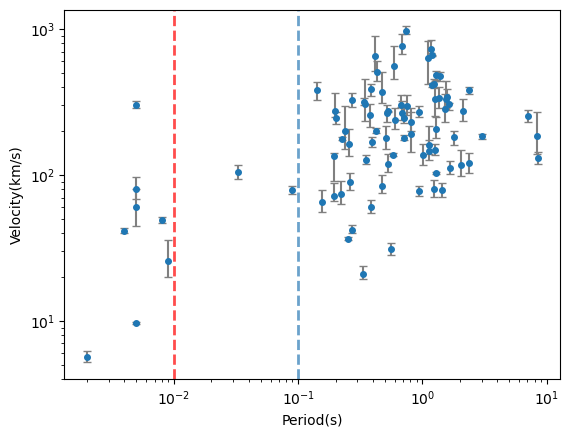

In [17]:
import matplotlib.pyplot as plt
err_up = np.array(dist_up_1_new)   
err_low = np.array(dis_low_1_new)
p_min = dist_1_new - err_low
p_max = dist_1_new + err_up
v_max_bound = (4.74 / p_min) * pmtot_1_new
v_min_bound = (4.74 / p_max) * pmtot_1_new
v_central = (4.74 / dist_1_new) * pmtot_1_new
v_err_up = v_max_bound - v_central   # 速度的上误差
v_err_low = v_central - v_min_bound  # 速度的下误差
plt.errorbar(period_1_new, v_central, yerr=[v_err_low, v_err_up], fmt='o', ecolor='gray', capsize=3, markersize=4)
#plt.errorbar(period_1, v_central_100, yerr=[v_err_low_100, v_err_up_100], fmt='o', ecolor='lightgray', capsize=3, markersize=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Period(s)')
plt.ylabel('Velocity(km/s)')
plt.axvline(x=0.01, color='red', linestyle='--', linewidth=2, alpha=0.7, label='x=0.01')
plt.axvline(x=0.1, color='#2C7BB6', linestyle='--', linewidth=2, alpha=0.7, label='x=0.01')

#plt.title('Period vs Transverse Velocity with Error Bars')
#plt.xlim(0.1,10)
plt.show()


In [67]:
np.savetxt('/Users/lizheng/Desktop/code/period_velocity/period_87_data.txt',period_1_new)

In [76]:
np.savetxt('/Users/lizheng/Desktop/code/period_velocity/vtrans_87_data.txt',v_central)

In [77]:
np.savetxt('/Users/lizheng/Desktop/code/period_velocity/v_rr_low_87_data.txt',v_err_low)

In [78]:
np.savetxt('/Users/lizheng/Desktop/code/period_velocity/v_err_up_87_data.txt',v_err_up)